In [1]:
from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random


In [2]:
!pip install ultralytics -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.8 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [4]:
%pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="__________________________") # using api to download dataset from roboflow
project = rf.workspace("youssefs-workspace-hdki7").project("apple_positivenegativa-lvm9k")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple_PositiveNegativa-1 in yolov8:: 100%|██████████| 1287/1287 [00:00<00:00, 2947.54it/s]


In [8]:
def check_structure(dataset_path: Path):
    print("\n📁 Structure du dataset :")
    dataset_path = Path(dataset_path)
    for split in ["train", "valid", "test"]:
        split_dir = dataset_path / split
        if not split_dir.exists():
            print(f"  ⚠️  {split}/ introuvable")
            continue
        img_dir = split_dir / "images"
        lbl_dir = split_dir / "labels"
        n_img = len(list(img_dir.glob("*.*"))) if img_dir.exists() else 0
        n_lbl = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
        status = "✅" if n_img == n_lbl and n_img > 0 else "⚠️"
        print(f"  {status} {split}/  images={n_img}  labels={n_lbl}")

In [9]:
DATASET_PATH = dataset.location
print("📍 Dataset téléchargé dans :", DATASET_PATH)
check_structure(DATASET_PATH)

📍 Dataset téléchargé dans : /content/Apple_PositiveNegativa-1

📁 Structure du dataset :
  ✅ train/  images=449  labels=449
  ✅ valid/  images=96  labels=96
  ✅ test/  images=96  labels=96


In [10]:
def read_data_yaml(dataset_path: Path):
    dataset_path = Path(dataset_path)
    yaml_path = dataset_path / "data.yaml"
    if not yaml_path.exists():
        print("\n⚠️  data.yaml introuvable — vérifie manuellement les classes.")
        return None
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    print(f"\n🏷️  Classes ({data.get('nc')}) : {data.get('names')}")
    return data

read_data_yaml(DATASET_PATH)


🏷️  Classes (1) : ['apple']


{'names': ['apple'],
 'nc': 1,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'apple_positivenegativa-lvm9k',
  'url': 'https://universe.roboflow.com/youssefs-workspace-hdki7/apple_positivenegativa-lvm9k/dataset/1',
  'version': 1,
  'workspace': 'youssefs-workspace-hdki7'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [11]:
def visualize_samples(dataset_path: Path, split: str = "train", n_samples: int = 6):
    dataset_path = Path(dataset_path)
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"
    images = list(img_dir.glob("*.*"))
    if not images:
        print(f"Aucune image trouvée dans {img_dir}")
        return

    samples = random.sample(images, min(n_samples, len(images)))
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = lbl_dir / (img_path.stem + ".txt")
        n_boxes = 0
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    _, xc, yc, bw, bh = map(float, parts)
                    # dénormaliser
                    x = (xc - bw / 2) * w
                    y = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h
                    rect = patches.Rectangle(
                        (x, y), box_w, box_h,
                        linewidth=1.5, edgecolor="lime", facecolor="none"
                    )
                    ax.add_patch(rect)
                    n_boxes += 1

        ax.set_title(f"{img_path.name}\n{n_boxes} pommes annotées", fontsize=9)
        ax.axis("off")

    # cacher les axes vides restants
    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    out_path = dataset_path / f"eda_preview_{split}.png"
    plt.savefig(out_path, dpi=120)
    print(f"\n🖼️  Aperçu sauvegardé : {out_path}")
    plt.show()


🖼️  Aperçu sauvegardé : /content/Apple_PositiveNegativa-1/eda_preview_train.png


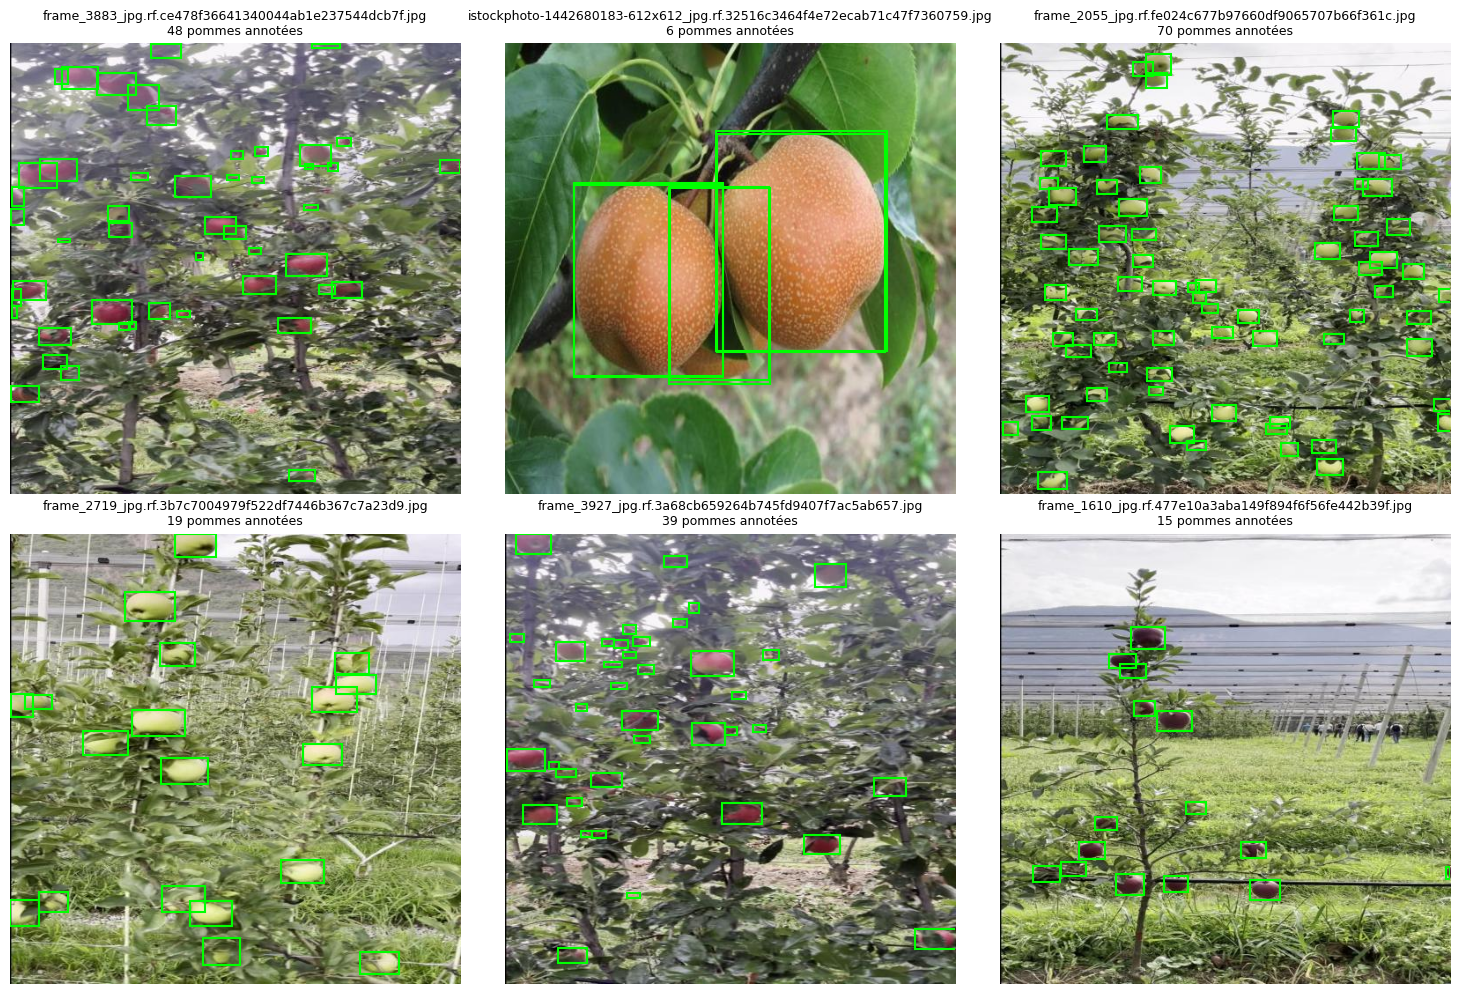

In [12]:
visualize_samples(DATASET_PATH, split="train", n_samples=6)


In [13]:
# Vérifier que le GPU est bien détecté
print("🖥️  GPU disponible :", torch.cuda.is_available())
print("🖥️  Device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Charger le modèle pré-entraîné YOLOv8n (le plus léger, idéal pour une baseline rapide)
model = YOLO("yolov8n.pt")

# Chemin vers le data.yaml téléchargé par Roboflow
data_yaml = f"{DATASET_PATH}/data.yaml"



🖥️  GPU disponible : True
🖥️  Device : Tesla T4


In [14]:
# Lancer l'entraînement baseline
results = model.train(
    data=data_yaml,
    epochs=20,
    imgsz=640,
    batch=16,
    name="apple_baseline",   # crée un dossier runs/detect/apple_baseline
    patience=10,              # arrête si pas d'amélioration après 10 epochs
)

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Apple_PositiveNegativa-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=apple_baseline, nbs=64, nms=None,

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import shutil
import os

# Dossier de destination sur ton Drive
drive_project_dir = "/content/drive/MyDrive/apple_counting_project"
os.makedirs(drive_project_dir, exist_ok=True)

# Copier tout le dossier de résultats (poids + courbes + logs)
save_dir = str(model.trainer.save_dir)  # ex: runs/detect/apple_baseline
dest = os.path.join(drive_project_dir, os.path.basename(save_dir))
shutil.copytree(save_dir, dest, dirs_exist_ok=True)

print(f"✅ Modèle sauvegardé dans : {dest}")
print(f"📦 Poids best.pt : {dest}/weights/best.pt")

✅ Modèle sauvegardé dans : /content/drive/MyDrive/apple_counting_project/apple_baseline
📦 Poids best.pt : /content/drive/MyDrive/apple_counting_project/apple_baseline/weights/best.pt


In [17]:
from ultralytics import YOLO

# Charger le meilleur modèle entraîné
model = YOLO("runs/detect/apple_baseline/weights/best.pt")

# Prédire sur tout le split test
results = model.predict(
    source=f"{DATASET_PATH}/test/images",
    conf=0.25,       # seuil de confiance minimum
    save=True,        # sauvegarde les images annotées
)

# Afficher le comptage par image
for r in results:
    print(f"{r.path.split('/')[-1]} → {len(r.boxes)} pommes détectées")


image 1/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image116_png_jpg.rf.e1b3c481a1458e93499788eda8b3bf0a.jpg: 640x640 95 apples, 7.2ms
image 2/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image11_png_jpg.rf.abe32771b63227014dd6ed1054eaefe0.jpg: 640x640 76 apples, 7.5ms
image 3/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image131_png_jpg.rf.b9277e19229b888e43d6393109807931.jpg: 640x640 103 apples, 9.1ms
image 4/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image201_png_jpg.rf.6899b40155838f0c9634edc8ea0eb2ad.jpg: 640x640 88 apples, 7.2ms
image 5/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image206_png_jpg.rf.311eb7e6c985375601cede464e95f059.jpg: 640x640 78 apples, 7.2ms
image 6/96 /content/Apple_PositiveNegativa-1/test/images/20150919_174151_image36_png_jpg.rf.d7f96850dc2614bd86b7e3d5f30f75e0.jpg: 640x640 78 apples, 7.2ms
image 7/96 /content/Apple_PositiveNegativa-1/test/images/2015091

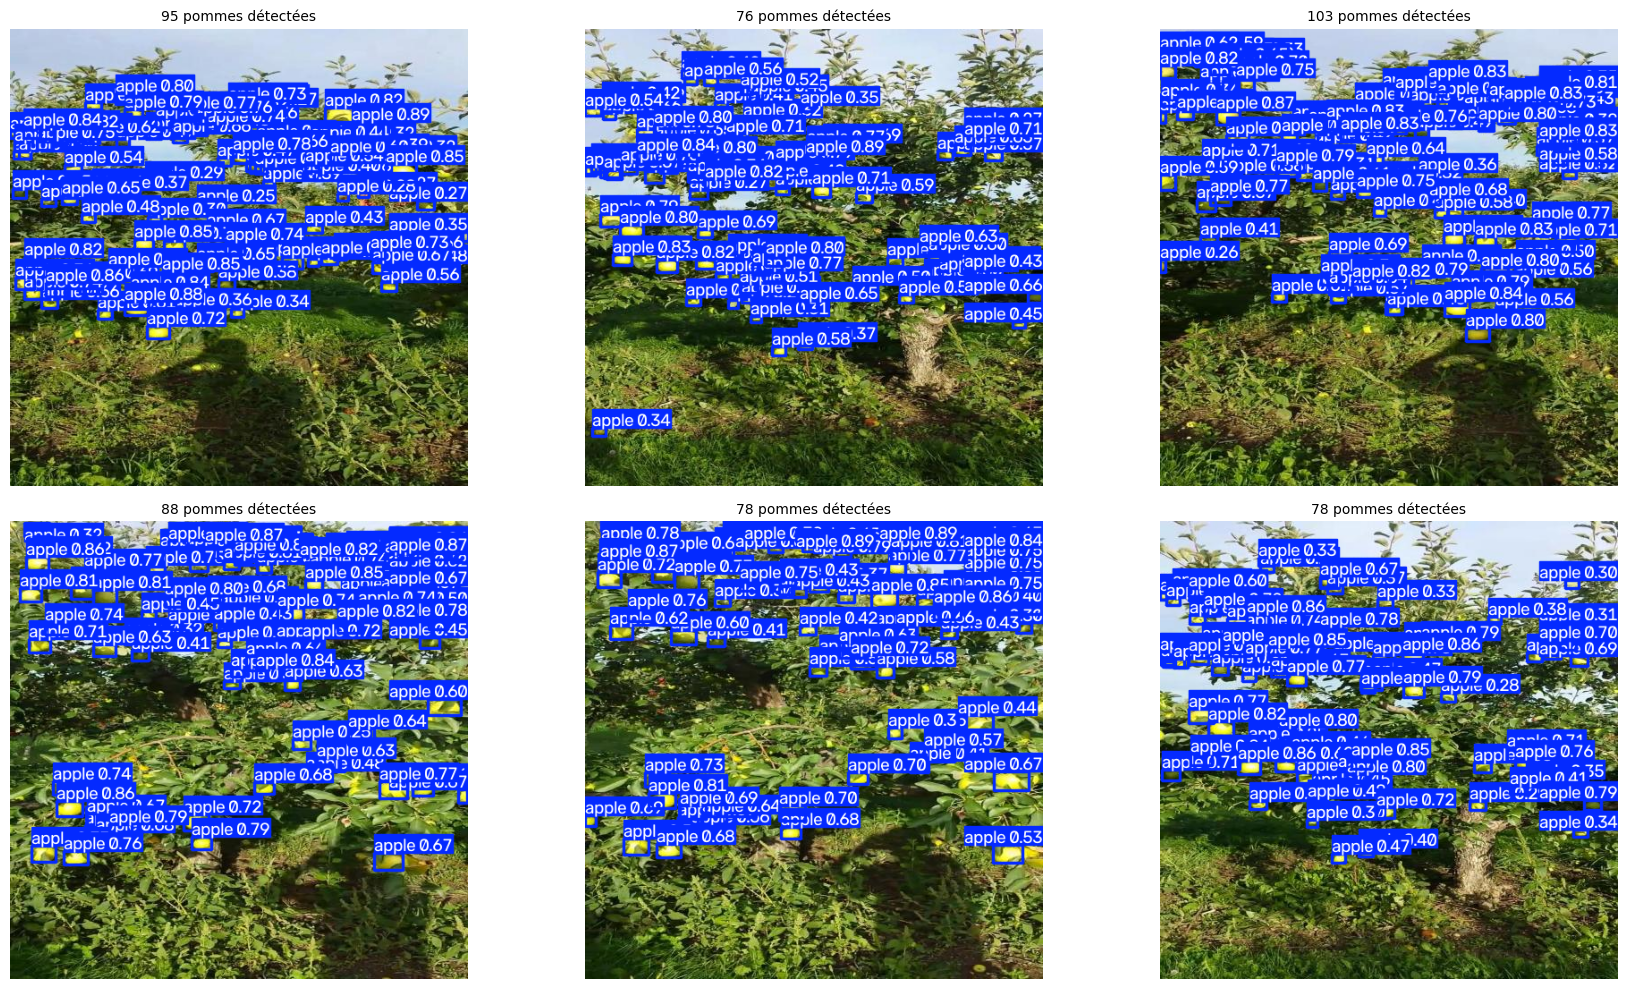

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, r in zip(axes, results[:6]):
    im = r.plot()  # image avec les bounding boxes dessinées par Ultralytics
    ax.imshow(im[..., ::-1])  # BGR → RGB
    ax.set_title(f"{len(r.boxes)} pommes détectées", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
import requests

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRt90WF22omWgkr3Q5oyoVuTzDwwsfrWG5p9oEVlQ3tGA&s=10"
img_path = "test_web_image.jpg"

response = requests.get(url)
with open(img_path, "wb") as f:
    f.write(response.content)

print("✅ Image téléchargée :", img_path)

✅ Image téléchargée : test_web_image.jpg



image 1/1 /content/test_web_image.jpg: 544x640 3 apples, 42.0ms
Speed: 3.2ms preprocess, 42.0ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict
🍎 3 pommes détectées


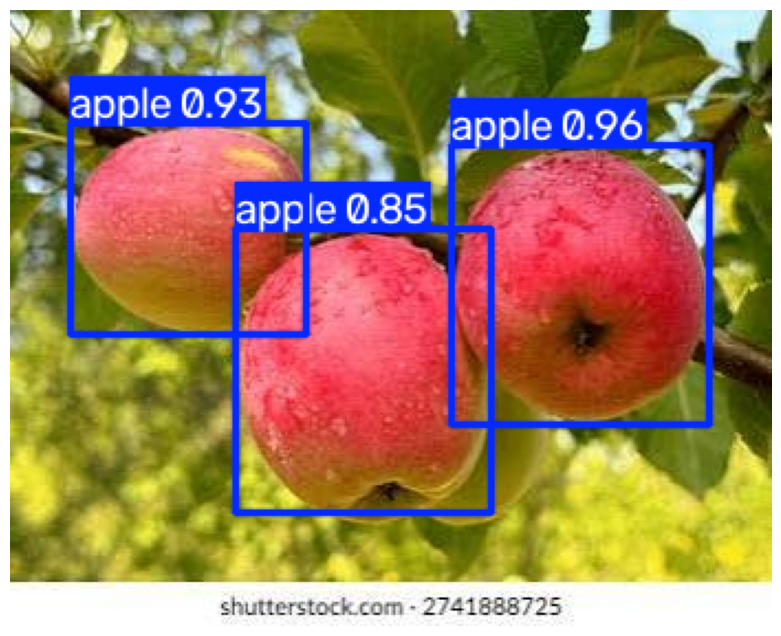

In [32]:
result = model.predict(source=img_path, conf=0.50, save=True)[0]
print(f"🍎 {len(result.boxes)} pommes détectées")

plt.figure(figsize=(10, 8))
plt.imshow(result.plot()[..., ::-1])
plt.axis("off")
plt.show()

In [33]:
# Modèle plus gros et plus précis que yolov8n
model_full = YOLO("yolov8s.pt")

results_full = model_full.train(
    data=data_yaml,              # même data.yaml qu'avant
    epochs=80,
    imgsz=640,
    batch=16,
    name="apple_full",
    patience=15,                  # arrête si pas d'amélioration après 15 epochs (évite l'overfitting inutile)
    project="/content/drive/MyDrive/apple_counting_project/runs",  # ← sauvegarde direct sur Drive

    # Augmentations renforcées par rapport aux valeurs par défaut
    mosaic=1.0,        # déjà actif par défaut
    fliplr=0.5,         # flip horizontal aléatoire
    hsv_h=0.015,        # variation teinte
    hsv_s=0.7,           # variation saturation
    hsv_v=0.4,           # variation luminosité
    degrees=10.0,        # légère rotation (utile pour angles de prise de vue variés)
    scale=0.5,           # zoom aléatoire (bon pour la variété de densité de pommes)
)

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Apple_PositiveNegativa-1/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=apple_full, nbs=64, nms=None, op

In [34]:
model_full = YOLO("/content/drive/MyDrive/apple_counting_project/runs/apple_full/weights/best.pt")

metrics = model_full.val(data=data_yaml, split="test")
print(f"mAP50    : {metrics.box.map50:.3f}")
print(f"mAP50-95 : {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall   : {metrics.box.mr:.3f}")

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 13.1±8.1 MB/s, size: 62.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/Apple_PositiveNegativa-1/test/labels... 96 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 96/96 208.0it/s 0.5s
val: New cache created: /content/Apple_PositiveNegativa-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5s/it 9.3s
                   all         96       3544      0.899      0.832      0.902      0.558
Speed: 8.2ms preprocess, 12.5ms inference, 0.0ms loss, 8.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP50    : 0.902
mAP50-95 : 0.558
Precision: 

In [35]:
import os, statistics

test_img_dir = f"{DATASET_PATH}/test/images"
test_lbl_dir = f"{DATASET_PATH}/test/labels"

errors = []
for img_file in sorted(os.listdir(test_img_dir)):
    img_path = os.path.join(test_img_dir, img_file)
    lbl_path = os.path.join(test_lbl_dir, img_file.rsplit(".", 1)[0] + ".txt")

    real_count = sum(1 for _ in open(lbl_path)) if os.path.exists(lbl_path) else 0
    pred_count = len(model_full.predict(source=img_path, conf=0.25, verbose=False)[0].boxes)

    errors.append(pred_count - real_count)

print(f"📊 Écart moyen (biais) : {statistics.mean(errors):+.1f} pommes")
print(f"📊 Écart absolu moyen  : {statistics.mean([abs(e) for e in errors]):.1f} pommes")
print(f"📊 Écart-type          : {statistics.stdev(errors):.1f}")

📊 Écart moyen (biais) : +0.6 pommes
📊 Écart absolu moyen  : 3.8 pommes
📊 Écart-type          : 5.8
